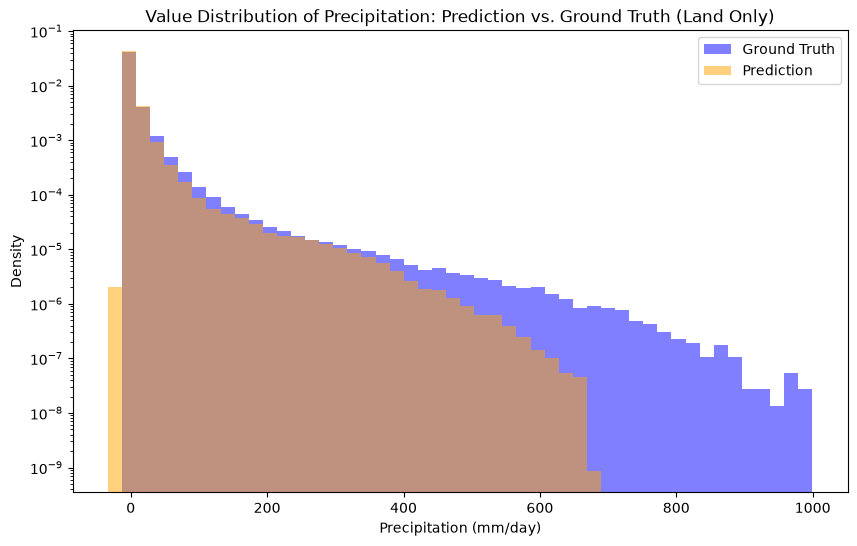

In [1]:
# ==========================================
# Q1: Is the value distribution of the output precipitation variable
# similar to that of the ground-truth precipitation variable over the whole year?
#
# 策略：
# 僅保留陸地資料，將全年 Ground Truth 與 64 個 ensemble prediction 的降雨值，
# 使用相同區間的 normalized histogram 進行比較，並以 log scale 觀察高降雨量尾端。
#
# 結論：
# Prediction 與 Ground Truth 的整體降雨量分布相似，
# 但 Prediction 在高降雨量區間的分布密度較低，顯示模型低估極端降雨事件，
# 並且出現少量負降雨量的預測值。
#
# 圖表證據：
# 在低至中等降雨量區間兩者高度重疊，但 Ground Truth 的高降雨量右尾明顯較長；
# Prediction 的分布則較早下降，且左側可觀察到少量小於 0 的降雨預測。
# ==========================================

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 1. 開啟檔案
main_data_path = 'output_0_all.nc'
mask_data_path = 'wrf_208x208_grid_coords.nc'

dataset = nc.Dataset(main_data_path, 'r')
mask_dataset = nc.Dataset(mask_data_path, 'r')

# 2. 取得陸地 Mask，LANDMASK = 1 代表陸地
land_mask = mask_dataset.variables['LANDMASK'][:]
land_only = land_mask == 1

# 3. 取得全年降雨量資料
# Truth shape: (365天, 208, 208)
truth_precip = dataset.groups['truth'].variables['precipitation'][:]

# Prediction shape: (64個ensemble, 365天, 208, 208)
pred_precip = dataset.groups['prediction'].variables['precipitation'][:]

# 4. 僅保留陸地格點，並攤平成一維資料以分析全年 value distribution
truth_land_only = truth_precip[..., land_only].flatten()
pred_land_only = pred_precip[..., land_only].flatten()

plt.figure(figsize=(10, 6))
hist_min = min(np.min(truth_land_only), np.min(pred_land_only))
hist_max = max(np.max(truth_land_only), np.max(pred_land_only))
shared_bins = np.linspace(hist_min, hist_max, 51)

plt.hist(truth_land_only, bins=shared_bins, alpha=0.5, label='Ground Truth', color='blue', density=True)
plt.hist(pred_land_only, bins=shared_bins, alpha=0.5, label='Prediction', color='orange', density=True)

plt.title('Value Distribution of Precipitation: Prediction vs. Ground Truth (Land Only)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Density')
plt.yscale('log')
plt.legend()

plt.show()

dataset.close()
mask_dataset.close()

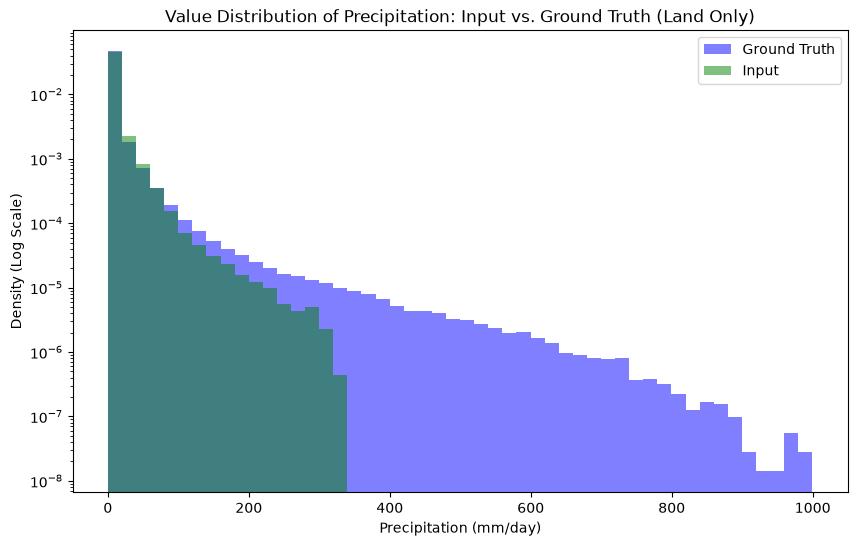

In [2]:
# ==========================================
# Q2: Is the value distribution of the input precipitation variable
# similar to that of the ground-truth precipitation variable over the whole year?
#
# 策略：
# 僅保留陸地資料，將全年 Input 與 Ground Truth 的降雨量資料攤平成一維資料，
# 並使用相同區間的 normalized histogram 比較兩者的數值分布，以 log scale 觀察高降雨量尾端。
#
# 結論：
# Input 與 Ground Truth 在低降雨量區間的分布大致相近，
# 但 Input 在中高降雨量區間的分布明顯較低，無法完整呈現較強的降雨事件。
#
# 圖表證據：
# 低降雨量區域的兩個 histogram 有較多重疊，
# 但 Ground Truth 的右尾延伸得更遠，而 Input 在高降雨量區域較早下降。
# ==========================================

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 1. 開啟檔案 (使用相對路徑)
main_data_path = 'output_0_all.nc'  
mask_data_path = 'wrf_208x208_grid_coords.nc' 
dataset = nc.Dataset(main_data_path, 'r')
mask_dataset = nc.Dataset(mask_data_path, 'r')

# 2. 取得陸地過濾網 (LANDMASK)
land_mask = mask_dataset.variables['LANDMASK'][:] 

# 3. 取得一整年的「降雨量」資料 (注意這次是抓取 truth 和 input 群組)
truth_precip = dataset.groups['truth'].variables['precipitation'][:]
input_precip = dataset.groups['input'].variables['precipitation'][:]

# 4. 過濾出陸地資料，並將所有數字攤平變成一維陣列
truth_land_only = truth_precip[..., land_mask == 1].flatten()
input_land_only = input_precip[..., land_mask == 1].flatten()

# 5. 開始畫圖！
plt.figure(figsize=(10, 6))

hist_min = min(np.min(truth_land_only), np.min(input_land_only))
hist_max = max(np.max(truth_land_only), np.max(input_land_only))
shared_bins = np.linspace(hist_min, hist_max, 51)

plt.hist(truth_land_only, bins=shared_bins, alpha=0.5, label='Ground Truth', color='blue', density=True)
plt.hist(input_land_only, bins=shared_bins, alpha=0.5, label='Input', color='green', density=True)

# 加上標題與標籤
plt.title('Value Distribution of Precipitation: Input vs. Ground Truth (Land Only)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Density (Log Scale)')
plt.legend() # 顯示圖例

# 將 Y 軸設為對數尺度 (Log Scale)，方便觀察極端降雨量
plt.yscale('log')

# 把圖顯示出來
plt.show()

# 關閉檔案
dataset.close()
mask_dataset.close()

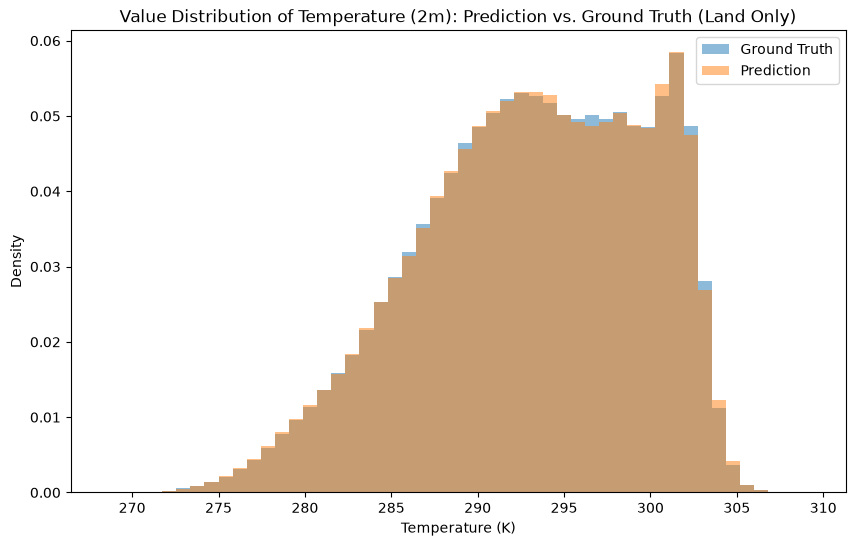

In [3]:
# ==========================================
# Q3: Is the value distribution of the output temperature variable
# similar to that of the ground-truth temperature variable over the whole year?
#
# 策略：
# 僅保留陸地資料，將全年 Ground Truth 與 64 個 ensemble Prediction 的溫度值
# 攤平成一維資料，使用相同的 histogram bins 與 normalized histogram 比較兩者分布。
#
# 結論：
# Prediction 與 Ground Truth 的溫度分布高度相似，
# 顯示模型能夠良好重現全年溫度的整體數值分布。
#
# 圖表證據：
# Prediction 與 Ground Truth 的 histogram 在大部分溫度區間幾乎重疊，
# 且兩者的主要分布範圍與分布形狀皆十分接近。
# ==========================================

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 1. 開啟檔案 (使用相對路徑)
main_data_path = 'output_0_all.nc'  
mask_data_path = 'wrf_208x208_grid_coords.nc' 
dataset = nc.Dataset(main_data_path, 'r')
mask_dataset = nc.Dataset(mask_data_path, 'r')

# 2. 取得陸地過濾網 (LANDMASK)
land_mask = mask_dataset.variables['LANDMASK'][:] 

# 3. 取得一整年的「溫度」資料 (注意變數名稱已經換成 temperature_2m)
truth_temp = dataset.groups['truth'].variables['temperature_2m'][:]
pred_temp = dataset.groups['prediction'].variables['temperature_2m'][:]

# 4. 過濾出陸地資料，並攤平成一維陣列
truth_land_only = truth_temp[..., land_mask == 1].flatten()
pred_land_only = pred_temp[..., land_mask == 1].flatten()

# 5. 開始畫圖！
plt.figure(figsize=(10, 6))

hist_min = min(np.min(truth_land_only), np.min(pred_land_only))
hist_max = max(np.max(truth_land_only), np.max(pred_land_only))
shared_bins = np.linspace(hist_min, hist_max, 51)

plt.hist(truth_land_only, bins=shared_bins, alpha=0.5, label='Ground Truth', density=True)
plt.hist(pred_land_only, bins=shared_bins, alpha=0.5, label='Prediction', density=True)

# 加上標題與標籤
plt.title('Value Distribution of Temperature (2m): Prediction vs. Ground Truth (Land Only)')
plt.xlabel('Temperature (K)')
plt.ylabel('Density')
plt.legend() # 顯示圖例

# 把圖顯示出來
plt.show()

# 關閉檔案釋放記憶體
dataset.close()
mask_dataset.close()

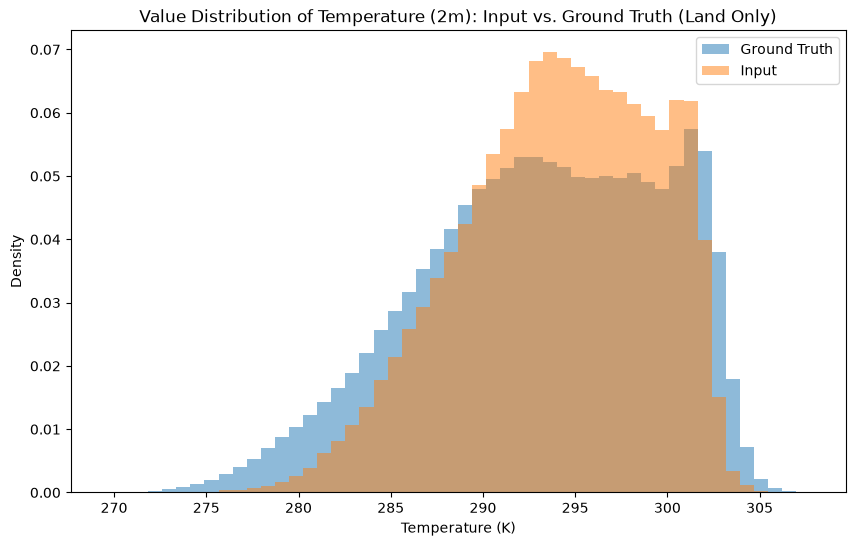

In [4]:
# ==========================================
# Q4: Is the value distribution of the input temperature variable
# similar to that of the ground-truth temperature variable over the whole year?
#
# 策略：
# 僅保留陸地資料，將全年 Input 與 Ground Truth 的溫度值攤平成一維資料，
# 使用相同的 histogram bins 與 normalized histogram 比較兩者的數值分布。
#
# 結論：
# Input與Ground Truth 相比窄了一點(高溫與低溫低於實際值，中段則是高於實際值)
#
# 圖表證據：
# 兩個 histogram 的主要溫度範圍大致重疊，
# 但在低溫區間 Ground Truth 的分布較明顯，而 Input 的分布較集中。
# ==========================================
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 1. 開啟檔案 (使用相對路徑)
main_data_path = 'output_0_all.nc'  
mask_data_path = 'wrf_208x208_grid_coords.nc' 
dataset = nc.Dataset(main_data_path, 'r')
mask_dataset = nc.Dataset(mask_data_path, 'r')

# 2. 取得陸地過濾網 (LANDMASK)
land_mask = mask_dataset.variables['LANDMASK'][:] 

# 3. 取得一整年的「溫度」資料 (注意這次是擷取 input 群組！)
truth_temp = dataset.groups['truth'].variables['temperature_2m'][:]
input_temp = dataset.groups['input'].variables['temperature_2m'][:]

# 4. 過濾出陸地資料，並攤平成一維陣列
truth_land_only = truth_temp[..., land_mask == 1].flatten()
input_land_only = input_temp[..., land_mask == 1].flatten()

# 5. 開始畫圖！
plt.figure(figsize=(10, 6))

hist_min = min(np.min(truth_land_only), np.min(input_land_only))
hist_max = max(np.max(truth_land_only), np.max(input_land_only))
shared_bins = np.linspace(hist_min, hist_max, 51)

plt.hist(truth_land_only, bins=shared_bins, alpha=0.5, label='Ground Truth', density=True)
plt.hist(input_land_only, bins=shared_bins, alpha=0.5, label='Input', density=True)

# 加上標題與標籤
plt.title('Value Distribution of Temperature (2m): Input vs. Ground Truth (Land Only)')
plt.xlabel('Temperature (K)')
plt.ylabel('Density')
plt.legend() # 顯示圖例

# 把圖顯示出來
plt.show()

# 關閉檔案釋放記憶體
dataset.close()
mask_dataset.close()

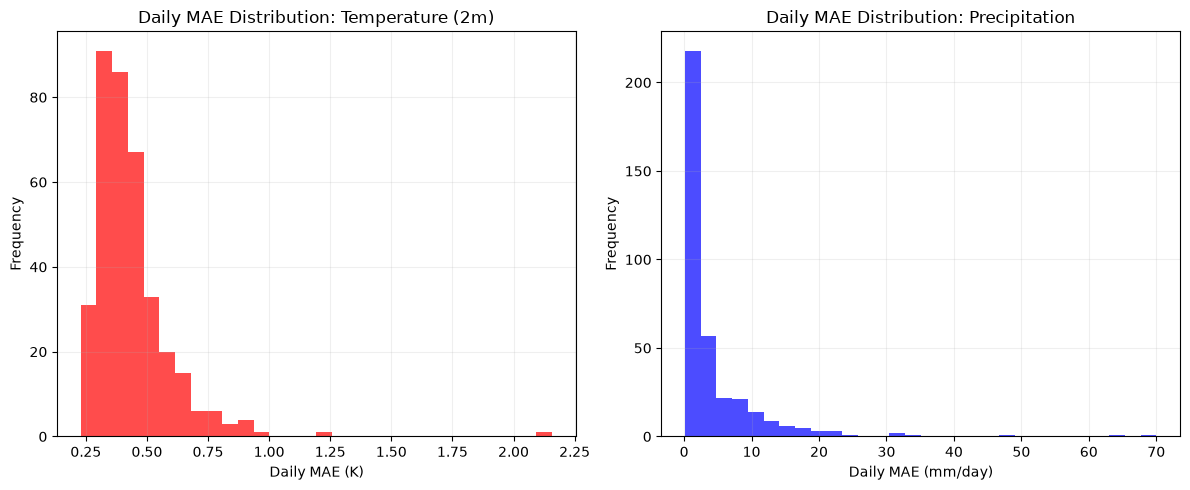

In [5]:
# ==========================================
# Q5: What are the distributions of Mean Absolute Error (MAE)
# for temperature variables and for precipitation variables?
#
# 策略：
# 先將每天 64 個 ensemble Prediction 取平均，再與 Ground Truth 比較。
# 對每個陸地格點計算絕對誤差，接著取所有陸地格點的平均，
# 得到每天一個 MAE，全年共 365 個 MAE，最後使用 histogram 分別觀察其分布。
#
# 結論：
# 溫度的每日 MAE 分布較集中，大部分約落在 0.3～0.6 K。
# 仍有少量較大的誤差，例如約 1.2 K、甚至 2.15 K
# 降雨量的每日 MAE 則呈明顯右偏，大部分日期誤差較小，
# 但少數日期會出現非常大的誤差，最高約可達 70 mm/day。
#
# 圖表證據：
# Temperature histogram 主要集中在約 0.3～0.6 K，
# 僅有少數日期的 MAE 超過 1 K。
# Precipitation histogram 則大量集中在低 MAE 區間，
# 並具有延伸至約 70 mm/day 的長右尾，顯示少數日期存在極大的降雨預測誤差。
# ==========================================

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 1. 載入資料與 Land Mask
main_data_path = 'output_0_all.nc'
mask_data_path = 'wrf_208x208_grid_coords.nc'

dataset = nc.Dataset(main_data_path, 'r')
mask_dataset = nc.Dataset(mask_data_path, 'r')

land_mask = mask_dataset.variables['LANDMASK'][:]
land_only = land_mask == 1

# 2. 讀取 Ground Truth
# Shape: (365, 208, 208)
truth_temp = dataset.groups['truth'].variables['temperature_2m'][:]
truth_precip = dataset.groups['truth'].variables['precipitation'][:]

# 3. 讀取 Prediction
# Shape: (64, 365, 208, 208)
# Dimensions: (ensemble, time, y, x)
pred_temp = dataset.groups['prediction'].variables['temperature_2m'][:]
pred_precip = dataset.groups['prediction'].variables['precipitation'][:]

# 4. 將 64 個 ensemble members 平均。
# axis=0 為 ensemble 維度，平均後 Shape 為 (365, 208, 208)。
pred_temp_mean = np.ma.mean(pred_temp, axis=0)
pred_precip_mean = np.ma.mean(pred_precip, axis=0)

# 5. 計算每一天、每一個 grid point 的 Absolute Error。
temp_absolute_error = np.abs(pred_temp_mean - truth_temp)
precip_absolute_error = np.abs(pred_precip_mean - truth_precip)

# 6. 只保留陸地 grid points。
# Shape 會從 (365, 208, 208) 變成 (365, 陸地格點數)。
temp_error_land = temp_absolute_error[:, land_only]
precip_error_land = precip_absolute_error[:, land_only]

# 7. 對每一天的所有陸地格點取平均，得到 365 個 Daily MAE。
temp_daily_mae = np.ma.mean(temp_error_land, axis=1)
precip_daily_mae = np.ma.mean(precip_error_land, axis=1)


# 8. 畫出 Daily MAE distributions。
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Temperature
axes[0].hist(temp_daily_mae, bins=30, color='red', alpha=0.7)
axes[0].set_title('Daily MAE Distribution: Temperature (2m)')
axes[0].set_xlabel('Daily MAE (K)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.2)

# Precipitation
axes[1].hist(precip_daily_mae, bins=30, color='blue', alpha=0.7)
axes[1].set_title('Daily MAE Distribution: Precipitation')
axes[1].set_xlabel('Daily MAE (mm/day)')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

dataset.close()
mask_dataset.close()

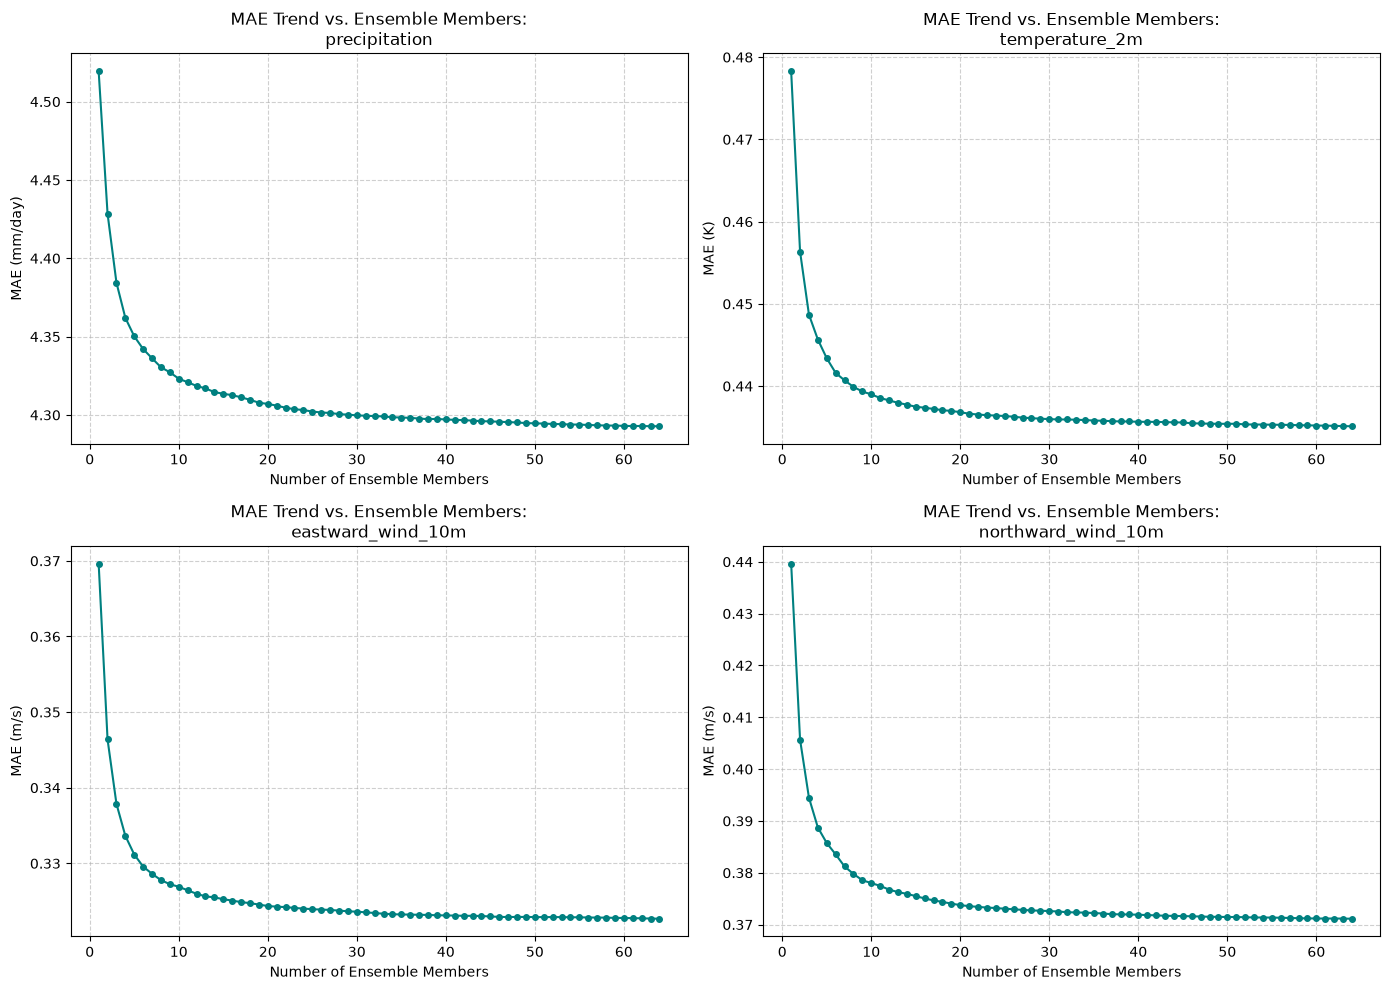

In [6]:
# ==========================================
# Q6: Does increasing the number of ensemble members improve the average prediction accuracy
# (measured by MAE)? Do all four output variables exhibit the same trend, or are there differences among them?
#
# 策略：
# 分別對 precipitation、temperature_2m、eastward_wind_10m 與 northward_wind_10m，
# 依序使用前 1～64 個 ensemble members 計算 ensemble mean，
# 再與 Ground Truth 比較，計算全年所有陸地格點的平均 MAE。
# 最後以折線圖觀察 ensemble members 數量增加時，各變數 MAE 的變化趨勢。
#
# 結論：
# 隨著 ensemble members 數量增加，四個變數的 MAE 皆呈下降趨勢，
# 表示增加 ensemble members 能提升平均預測準確度。
# 前幾個 members 帶來的改善最明顯，約在 10～20 個 members 後逐漸趨於平緩，
# 顯示增加 ensemble members 的效益具有邊際遞減現象。
# 四個變數的整體趨勢一致，但相對改善幅度不同，
# 其中兩個風速變數的相對 MAE 降幅較明顯，而降雨量的相對降幅較小。
#
# 圖表證據：
# 四張 MAE 曲線皆隨 ensemble members 增加而下降，
# 且曲線前段下降較快，約在 10～20 個 members 後逐漸趨平。
# 四個變數皆呈現相同的邊際效益遞減趨勢，
# 但各變數由 1 個增加至 64 個 ensemble members 時的相對 MAE 降幅有所不同。
# ==========================================

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 1. 載入資料與 Land Mask
dataset = nc.Dataset('output_0_all.nc', 'r')
mask_dataset = nc.Dataset('wrf_208x208_grid_coords.nc', 'r')

land_mask = mask_dataset.variables['LANDMASK'][:]
land_only = land_mask == 1

# 2. 四個模型輸出變數
variables = ['precipitation', 'temperature_2m', 'eastward_wind_10m', 'northward_wind_10m']

# 各變數對應單位，用於 Y 軸標示。
units = {
    'precipitation': 'mm/day',
    'temperature_2m': 'K',
    'eastward_wind_10m': 'm/s',
    'northward_wind_10m': 'm/s'
}

ensemble_sizes = range(1, 65)
mae_trends = {var: [] for var in variables}

# 3. 分別計算四個變數在 1~64 ensemble members 下的 MAE
for var in variables:

    # Truth shape: (365, 208, 208)
    truth_data = dataset.groups['truth'].variables[var][:]

    # Prediction shape: (64, 365, 208, 208)
    # Dimension order: (ensemble, time, y, x)
    pred_data = dataset.groups['prediction'].variables[var][:]

    # 累積 ensemble predictions，避免每次從第 1 個 member 重新計算平均。
    pred_cumsum = np.ma.cumsum(pred_data, axis=0)

    for n in ensemble_sizes:

        # 前 N 個 ensemble members 的平均 prediction。
        pred_n_mean = pred_cumsum[n - 1] / n

        # 計算每一天、每一個 grid point 的 Absolute Error。
        abs_error = np.ma.abs(pred_n_mean - truth_data)

        # 僅保留陸地 grid points，並對所有日期與陸地位置取平均得到 overall MAE。
        land_mae = np.ma.mean(abs_error[:, land_only])

        mae_trends[var].append(float(land_mae))

# 4. 繪製四個變數的 MAE 趨勢圖
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables):

    axes[i].plot(ensemble_sizes, mae_trends[var], marker='o', markersize=4, linestyle='-', color='teal')

    axes[i].set_title(f'MAE Trend vs. Ensemble Members:\n{var}')
    axes[i].set_xlabel('Number of Ensemble Members')
    axes[i].set_ylabel(f'MAE ({units[var]})')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

dataset.close()
mask_dataset.close()

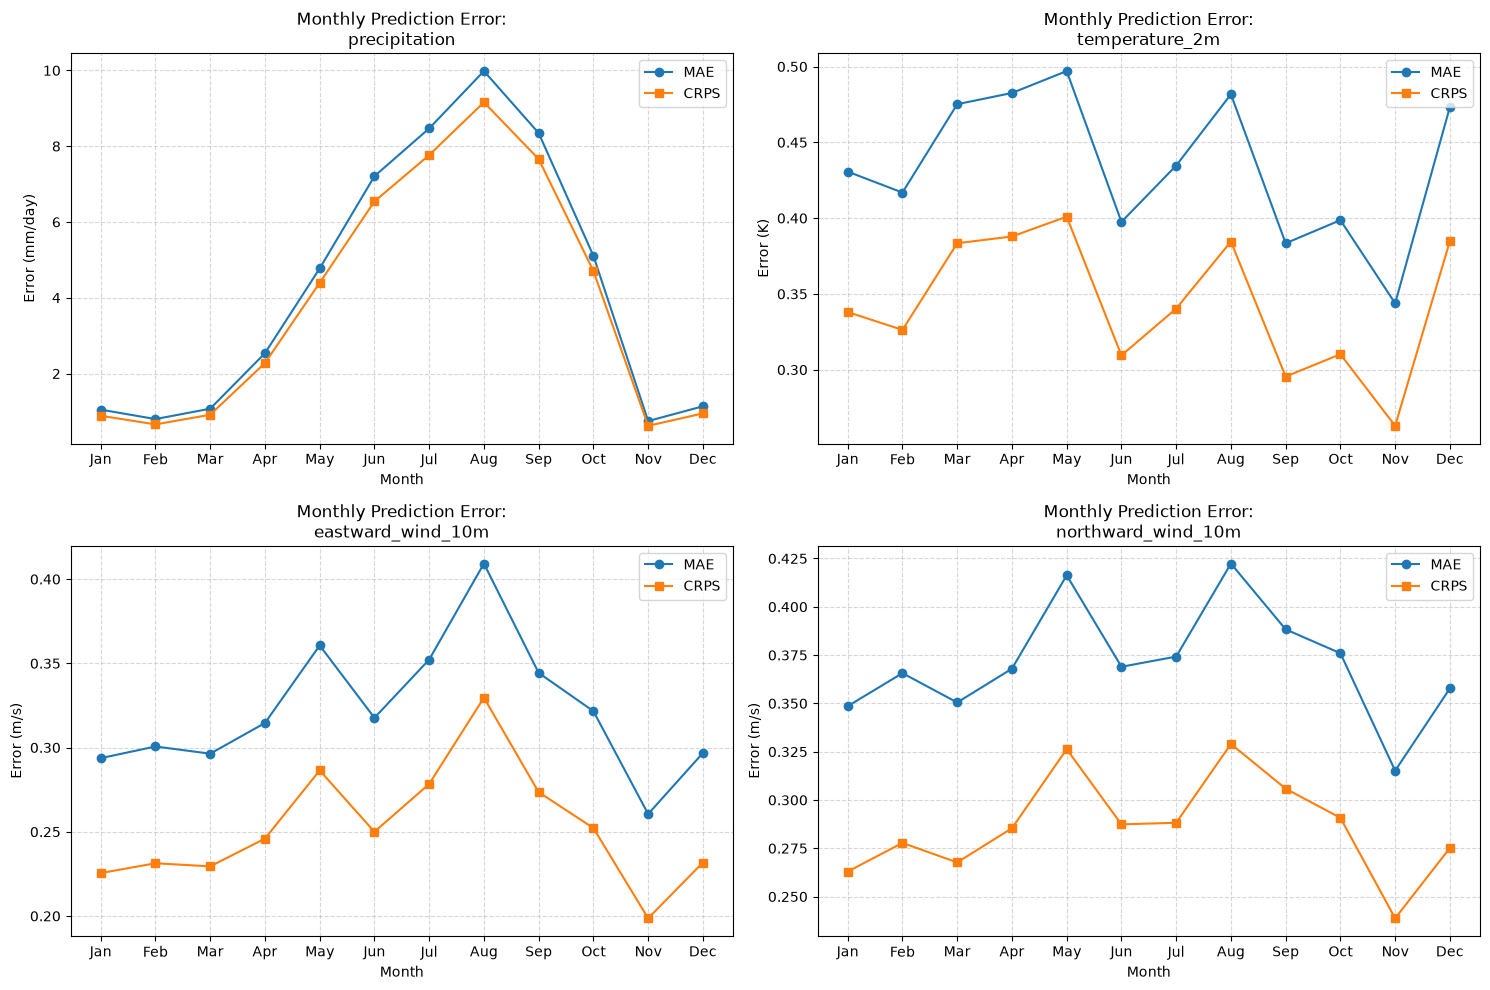

In [7]:
# ==========================================
# Q7: Are there any notable patterns in prediction error across different months or seasons?
# If evaluated by MAE and CRPS (Continuous Ranked Probability Score), do the patterns differ?
#
# 策略：
# 分別計算 precipitation、temperature_2m、eastward_wind_10m 與 northward_wind_10m
# 每一天在陸地區域的 MAE 與 CRPS，再依月份將每日結果分組並取平均。
# 最後以折線圖比較 1～12 月的 MAE 與 CRPS，觀察預測誤差是否具有月份或季節性變化。
#
# 結論：
# 四個變數的預測誤差皆會隨月份改變，其中降雨量的季節性變化最明顯。
# 降雨量在夏季的 MAE 與 CRPS 較高，並在 8 月達到最高。
# 整體而言，MAE 與 CRPS 的月份變化趨勢大致一致，
# 但兩種指標的誤差大小仍有所差異。
#
# 圖表證據：
# Precipitation 的 MAE 與 CRPS 在 6～9 月明顯升高，並於 8 月出現最高值，
# 之後在秋季逐漸下降。
# Temperature 與兩個 wind variables 也呈現月份波動，
# 且 MAE 與 CRPS 的高低月份大致相互對應。
# ==========================================

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 1. 開啟資料
dataset = nc.Dataset('output_0_all.nc', 'r')
mask_dataset = nc.Dataset('wrf_208x208_grid_coords.nc', 'r')

land_mask = mask_dataset.variables['LANDMASK'][:]
land_only = land_mask == 1

# 2. 讀取並轉換時間
time_var = dataset.variables['time']

dates = nc.num2date(
    time_var[:],
    units=time_var.units,
    calendar=time_var.calendar
)

# 每一天所屬月份，例如 [1, 1, ..., 2, 2, ...]
months = np.array([date.month for date in dates])

# 3. 四個輸出變數及其單位
variables = [
    'precipitation',
    'temperature_2m',
    'eastward_wind_10m',
    'northward_wind_10m'
]

units = {
    'precipitation': 'mm/day',
    'temperature_2m': 'K',
    'eastward_wind_10m': 'm/s',
    'northward_wind_10m': 'm/s'
}

# 儲存每個變數的 Daily MAE / CRPS
daily_mae_results = {}
daily_crps_results = {}

# Ensemble members 數量
ensemble_count = len(dataset.dimensions['ensemble'])

# CRPS 快速公式所需要的係數
# Ensemble predictions 排序後，可避免直接計算 64x64 的兩兩差異矩陣
crps_weights = (
    2 * np.arange(1, ensemble_count + 1)
    - ensemble_count
    - 1
).reshape(-1, 1)

# 4. 依序處理四個變數
for var in variables:

    truth_var = dataset.groups['truth'].variables[var]
    pred_var = dataset.groups['prediction'].variables[var]

    daily_mae = []
    daily_crps = []

    # 一天一天讀，避免一次將整年的 prediction 載入記憶體
    for day in range(len(dates)):

        # Truth shape: (208, 208)
        # 只留下陸地 → (land_grid_count,)
        truth_day = truth_var[day, :, :]
        truth_land = np.asarray(
            truth_day[land_only],
            dtype=np.float64
        )

        # Prediction shape: (64, 208, 208)
        # 只留下陸地 → (64, land_grid_count)
        pred_day = pred_var[:, day, :, :]
        pred_land = np.asarray(
            pred_day[:, land_only],
            dtype=np.float64
        )

        # -----------------------------
        # MAE
        # -----------------------------

        # 對 64 個 ensemble members 平均
        ensemble_mean = np.mean(pred_land, axis=0)

        # 每個 land grid 的 absolute error
        absolute_error = np.abs(
            ensemble_mean - truth_land
        )

        # 當天所有陸地 grid 的平均 → Daily MAE
        day_mae = np.mean(absolute_error)

        daily_mae.append(day_mae)

        # -----------------------------
        # CRPS
        # -----------------------------

        # 第一項：
        # 64 個 ensemble members 與 Ground Truth 的平均距離
        term1 = np.mean(
            np.abs(
                pred_land - truth_land[None, :]
            ),
            axis=0
        )

        # 將每個 grid 的 64 個 ensemble predictions 由小到大排序
        sorted_pred = np.sort(
            pred_land,
            axis=0
        )

        # 第二項：
        # Ensemble members 彼此之間的 spread
        term2 = (
            np.sum(
                crps_weights * sorted_pred,
                axis=0
            )
            / (ensemble_count ** 2)
        )

        # 每個 land grid 的 CRPS
        crps_grid = term1 - term2

        # 當天所有陸地 grid 的平均 → Daily CRPS
        day_crps = np.mean(crps_grid)

        daily_crps.append(day_crps)

    daily_mae_results[var] = np.array(daily_mae)
    daily_crps_results[var] = np.array(daily_crps)


# 5. 將 Daily MAE / CRPS 按照月份平均
monthly_mae_results = {}
monthly_crps_results = {}

for var in variables:

    monthly_mae = []
    monthly_crps = []

    for month in range(1, 13):

        month_mask = months == month

        monthly_mae.append(
            np.mean(
                daily_mae_results[var][month_mask]
            )
        )

        monthly_crps.append(
            np.mean(
                daily_crps_results[var][month_mask]
            )
        )

    monthly_mae_results[var] = np.array(monthly_mae)
    monthly_crps_results[var] = np.array(monthly_crps)


# 6. 畫出每個月份的 MAE 與 CRPS
month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

month_numbers = np.arange(1, 13)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(variables):

    axes[i].plot(
        month_numbers,
        monthly_mae_results[var],
        marker='o',
        label='MAE'
    )

    axes[i].plot(
        month_numbers,
        monthly_crps_results[var],
        marker='s',
        label='CRPS'
    )

    axes[i].set_title(
        f'Monthly Prediction Error:\n{var}'
    )

    axes[i].set_xlabel('Month')
    axes[i].set_ylabel(
        f'Error ({units[var]})'
    )

    axes[i].set_xticks(month_numbers)
    axes[i].set_xticklabels(month_labels)

    axes[i].grid(
        True,
        linestyle='--',
        alpha=0.5
    )

    axes[i].legend()

plt.tight_layout()
plt.show()





# 關閉 NetCDF
dataset.close()
mask_dataset.close()

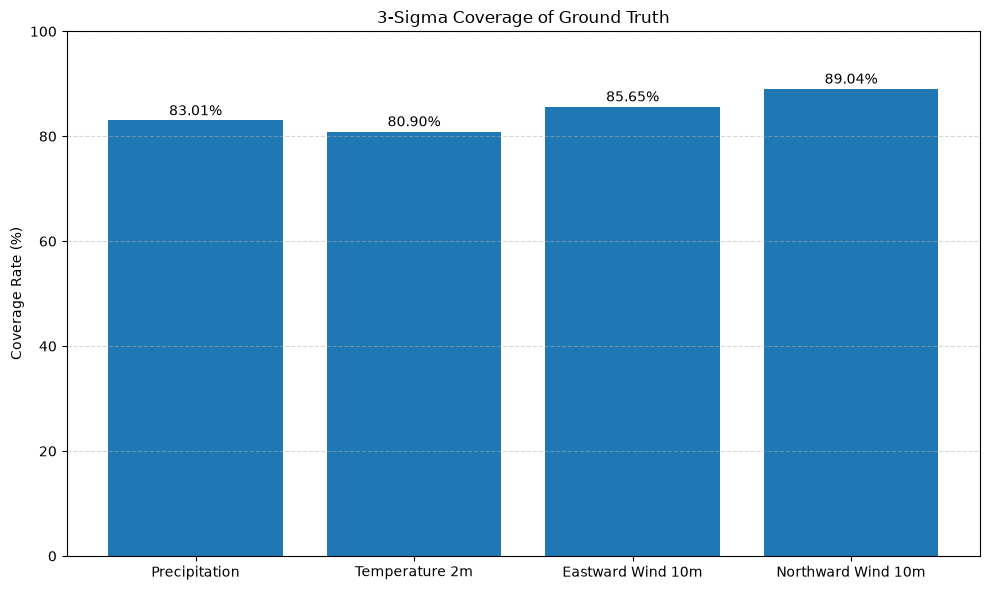

In [8]:
# ==========================================
# Q8: Does the 3-sigma uncertainty range adequately cover the ground truth?
# Are the conclusions consistent across all variables?
#
# 策略：
# 對四個輸出變數逐日計算 64 個 ensemble Prediction 的平均值與標準差，
# 並以 ensemble mean ± 3 × standard deviation 建立每個陸地格點的 3-sigma uncertainty range。
# 接著檢查 Ground Truth 是否落在此範圍內，最後計算全年所有陸地格點的 Coverage Rate。
#
# 結論：
# 四個變數的 3-sigma 範圍皆無法充分涵蓋 Ground Truth，
# Coverage 約為 81%～89%，明顯低於常態分布假設下 3-sigma 約 99.7% 的理論參考值。
# 四個變數的結論一致，其中 Northward Wind 的 Coverage 最高，而 Temperature 最低。
#
# 圖表證據：
# 四個變數的 Coverage Rate 皆低於 90%，
# Temperature 約為 80.90%，Precipitation 約為 83.01%，
# Eastward Wind 約為 85.65%，Northward Wind 約為 89.04%。
# 因此四個變數的 3-sigma uncertainty range 都仍有相當比例的 Ground Truth 落在範圍外。
# ==========================================

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 1. 載入資料與 Land Mask
dataset = nc.Dataset('output_0_all.nc', 'r')
mask_dataset = nc.Dataset('wrf_208x208_grid_coords.nc', 'r')

# 已確認資料有效，因此關閉 NetCDF 自動 MaskedArray
dataset.set_auto_mask(False)
mask_dataset.set_auto_mask(False)

land_mask = mask_dataset.variables['LANDMASK'][:]
land_only = land_mask == 1

# 2. 四個輸出變數
variables = [
    'precipitation',
    'temperature_2m',
    'eastward_wind_10m',
    'northward_wind_10m'
]

coverage_results = {}

# 3. 逐一處理四個變數
for var in variables:

    truth_var = dataset.groups['truth'].variables[var]
    pred_var = dataset.groups['prediction'].variables[var]

    covered_count = 0
    total_count = 0

    # 365 天逐日處理
    for day in range(len(dataset.dimensions['time'])):

        # Ground Truth shape: (208, 208)
        truth_day = np.asarray(
            truth_var[day, :, :],
            dtype=np.float64
        )

        # Prediction shape: (64, 208, 208)
        pred_day = np.asarray(
            pred_var[:, day, :, :],
            dtype=np.float64
        )

        # 4. 對 64 個 ensemble members 計算每個 grid 的平均與標準差
        # (64, 208, 208) → (208, 208)
        ensemble_mean = np.mean(pred_day, axis=0)
        ensemble_std = np.std(pred_day, axis=0)

        # 5. 建立完整 208×208 的 3-sigma uncertainty range
        lower_bound = ensemble_mean - 3 * ensemble_std
        upper_bound = ensemble_mean + 3 * ensemble_std

        # 6. 最後才取陸地資料
        truth_land = truth_day[land_only]
        lower_land = lower_bound[land_only]
        upper_land = upper_bound[land_only]

        # Ground Truth 是否落在 3-sigma range 內
        covered = (
            (truth_land >= lower_land)
            & (truth_land <= upper_land)
        )

        # 累積全年所有陸地 grid
        covered_count += np.sum(covered)
        total_count += covered.size

    # 7. 計算 Coverage Rate
    coverage_rate = covered_count / total_count * 100
    coverage_results[var] = coverage_rate


# 8. 畫圖
labels = [
    'Precipitation',
    'Temperature 2m',
    'Eastward Wind 10m',
    'Northward Wind 10m'
]

coverage_values = [
    coverage_results[var]
    for var in variables
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    labels,
    coverage_values
)

plt.title('3-Sigma Coverage of Ground Truth')
plt.ylabel('Coverage Rate (%)')
plt.ylim(0, 100)
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

# 在柱狀圖上顯示實際百分比
for bar, value in zip(bars, coverage_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f'{value:.2f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

# 關閉 NetCDF
dataset.close()
mask_dataset.close()

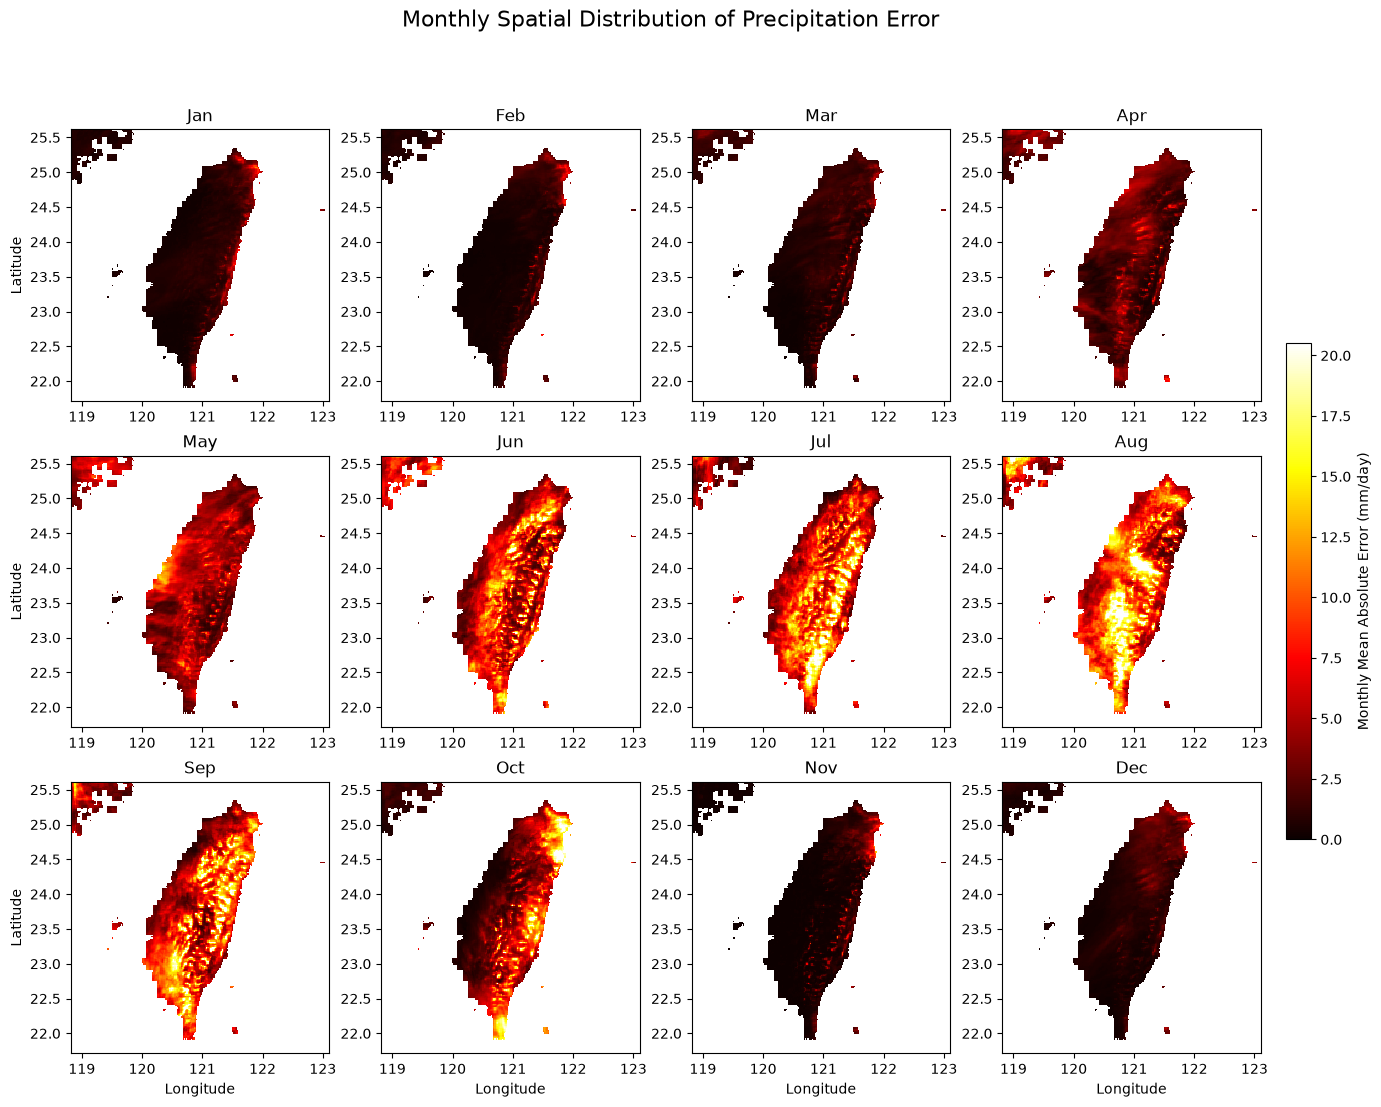

In [9]:
# ==========================================
# Q9: In different months, do the spatial patterns of high precipitation error areas differ?
#
# 策略：
# 對每一天的 64 個 ensemble precipitation predictions 取平均，
# 再與 Ground Truth 計算每個陸地格點的 Absolute Error。
# 接著依月份將每天的誤差累積並取平均，
# 得到 1～12 月各自的 Spatial MAE Map，
# 最後使用相同的 color scale 比較不同月份的降雨誤差空間分布。
#
# 結論：
# 降雨預測誤差的空間分布會隨月份明顯改變。
# 冬季的高誤差區域較少，而 6～9 月的高誤差範圍明顯擴大，
# 顯示降雨誤差的大小與空間分布皆具有季節性變化。
#
# 圖表證據：
# 1～3 月的高誤差區域較少且範圍較小，
# 春季開始逐漸增加，而 6～9 月可觀察到較大範圍的高 MAE 區域。
# 之後高誤差範圍逐漸減少，顯示不同月份的空間誤差模式並不相同。
# ==========================================

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 1. 載入資料與 Land Mask
dataset = nc.Dataset('output_0_all.nc', 'r')
mask_dataset = nc.Dataset('wrf_208x208_grid_coords.nc', 'r')

land_mask = mask_dataset.variables['LANDMASK'][:]
land_only = land_mask == 1

# 2. 取得日期資訊
time_var = dataset.variables['time']

dates = nc.num2date(
    time_var[:],
    units=time_var.units,
    calendar=time_var.calendar
)

months = np.array([date.month for date in dates])

# 3. 取得 precipitation variables
truth_var = dataset.groups['truth'].variables['precipitation']
pred_var = dataset.groups['prediction'].variables['precipitation']

# 用來儲存 12 個月份的 Spatial MAE Map
monthly_error_maps = []

# 4. 分別處理 1～12 月
for month in range(1, 13):

    # 找出該月份有哪些 day index
    day_indices = np.where(months == month)[0]

    # 用來累積該月份每個 grid 的 Absolute Error
    error_sum = np.zeros((208, 208), dtype=np.float64)

    for day in day_indices:

        # Truth shape: (208, 208)
        truth_day = np.asarray(
            truth_var[day, :, :],
            dtype=np.float64
        )

        # Prediction shape: (64, 208, 208)
        pred_day = np.asarray(
            pred_var[:, day, :, :],
            dtype=np.float64
        )

        # 對 64 個 ensemble members 取平均
        # shape: (208, 208)
        pred_mean = np.mean(pred_day, axis=0)

        # 每個 grid point 的 Absolute Error
        abs_error = np.abs(pred_mean - truth_day)

        # 只累積陸地 grid 的誤差
        error_sum[land_only] += abs_error[land_only]

    # 建立該月份的 Spatial MAE Map
    monthly_mae = np.full((208, 208), np.nan, dtype=np.float64)

    # 每個陸地 grid：
    # 該月份所有日期的 Absolute Error 總和 / 該月份天數
    monthly_mae[land_only] = (
        error_sum[land_only] / len(day_indices)
    )

    # Ocean 保持 NaN，不顯示
    monthly_error_maps.append(monthly_mae)

# Shape: (12, 208, 208)
monthly_error_maps = np.array(monthly_error_maps)

# 5. 讀取經緯度
lat = dataset.variables['lat'][:]
lon = dataset.variables['lon'][:]

# 所有月份使用相同的 color scale，才能公平比較空間誤差
all_land_errors = monthly_error_maps[:, land_only]

# 使用 99th percentile，避免少數極端值讓整體色階失去辨識度
vmax = np.nanpercentile(all_land_errors, 99)

month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

# 6. 畫出 12 個月份的降雨誤差空間分布
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

image = None

for i in range(12):

    image = axes[i].pcolormesh(
        lon,
        lat,
        monthly_error_maps[i],
        shading='auto',
        vmin=0,
        vmax=vmax,
        cmap='hot'
    )

    axes[i].set_title(month_labels[i])

    # 只在最下排顯示 Longitude
    if i >= 8:
        axes[i].set_xlabel('Longitude')

    # 只在最左欄顯示 Latitude
    if i % 4 == 0:
        axes[i].set_ylabel('Latitude')

# 12 張圖共用同一個 colorbar
fig.colorbar(
    image,
    ax=axes,
    orientation='vertical',
    fraction=0.02,
    pad=0.02,
    label='Monthly Mean Absolute Error (mm/day)'
)

fig.suptitle(
    'Monthly Spatial Distribution of Precipitation Error',
    fontsize=16
)

plt.show()

# 關閉 NetCDF
dataset.close()
mask_dataset.close()

90th percentile precipitation threshold: 12.9302 mm/day


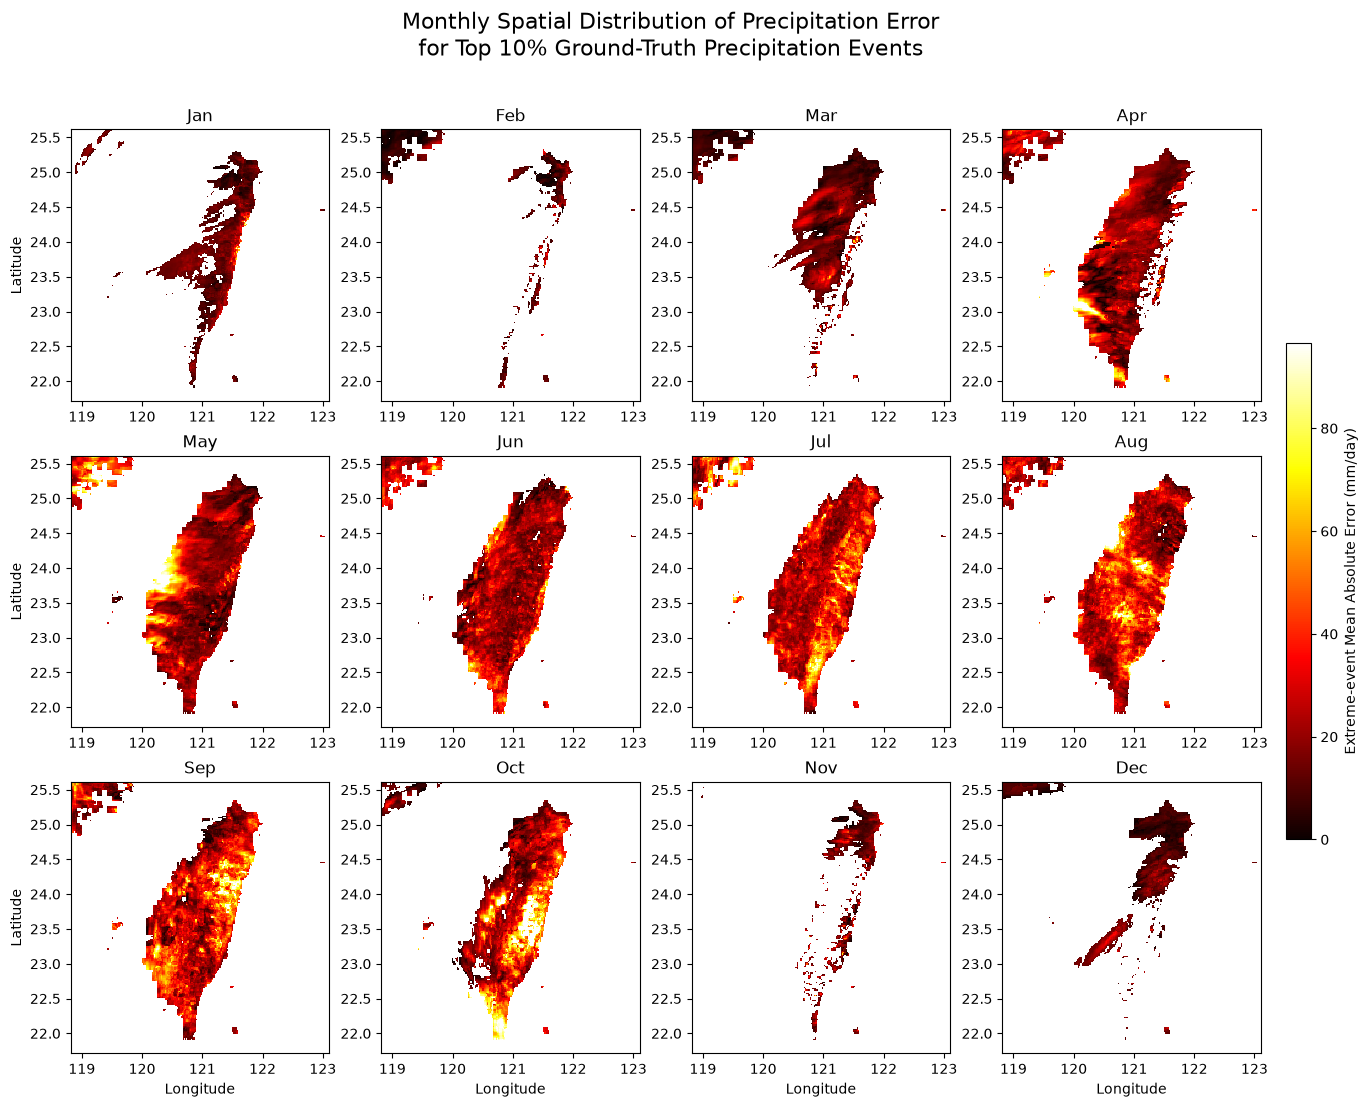

In [10]:
# ==========================================
# Q10: If we only consider the top 10% of the highest precipitation events,
# do the spatial patterns of high precipitation error areas differ across months?
#
# 策略：
# 先使用全年所有陸地格點的 Ground Truth precipitation，
# 計算第 90 百分位數作為 Top 10% 高降雨事件的門檻。
# 接著對每天的 64 個 ensemble precipitation predictions 取平均，
# 並與 Ground Truth 計算每個陸地格點的 Absolute Error。
# 只保留 Ground Truth 高於 Top 10% 門檻的降雨事件，
# 再依月份計算各格點在高降雨事件下的平均 Absolute Error，
# 最後以相同的 color scale 比較 1～12 月的空間誤差分布。
#
# 結論：
# 只考慮前 10% 的高降雨事件時，降雨預測誤差的空間分布仍會隨月份改變。
# 高誤差區域主要集中在 5～10 月，且誤差較強、分布也較集中。
# 冬季月份的高降雨事件較少，高誤差區域也相對較少。
# 相較於 Q9，Top 10% 高降雨事件的誤差空間分布更集中，且誤差幅度更大。
#
# 圖表證據：
# 1～2 月以及 11～12 月的高誤差區域相對較少，
# 而從春季開始，高降雨事件及其預測誤差逐漸增加。
# 約 5～10 月可以觀察到較明顯且集中的高 MAE 區域，
# 顯示高降雨事件的預測誤差具有明顯的月份與空間差異。
# ==========================================

import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt

# 1. 載入資料與 Land Mask
dataset = nc.Dataset('output_0_all.nc', 'r')
mask_dataset = nc.Dataset('wrf_208x208_grid_coords.nc', 'r')

# 已確認資料有效，因此關閉 NetCDF 自動 MaskedArray
dataset.set_auto_mask(False)
mask_dataset.set_auto_mask(False)

land_mask = mask_dataset.variables['LANDMASK'][:]
land_only = land_mask == 1

# 讀取經緯度
lat = dataset.variables['lat'][:]
lon = dataset.variables['lon'][:]

# 2. 取得日期資訊
time_var = dataset.variables['time']

dates = nc.num2date(
    time_var[:],
    units=time_var.units,
    calendar=time_var.calendar
)

months = np.array([date.month for date in dates])

# 3. 取得 precipitation variables
truth_var = dataset.groups['truth'].variables['precipitation']
pred_var = dataset.groups['prediction'].variables['precipitation']


# 4. 收集全年所有陸地的 Ground Truth precipitation
#    用來計算全年統一的 90th percentile threshold
truth_land_values = []

for day in range(len(dates)):

    # Ground Truth shape: (208, 208)
    truth_day = np.asarray(
        truth_var[day, :, :],
        dtype=np.float64
    )

    # 只取陸地格點
    truth_land_values.append(
        truth_day[land_only]
    )

# 將 365 天的陸地降雨資料合併
truth_land_values = np.concatenate(
    truth_land_values
)

# 90th percentile
# 大於等於此門檻的資料即視為 Top 10% 高降雨事件
extreme_threshold = np.percentile(
    truth_land_values,
    90
)

print(
    f'90th percentile precipitation threshold: '
    f'{extreme_threshold:.4f} mm/day'
)


# 5. 計算每個月份 Top 10% 高降雨事件的 Spatial MAE
monthly_extreme_error_maps = []

for month in range(1, 13):

    # 找出該月份有哪些 day index
    day_indices = np.where(months == month)[0]

    # 每個 grid 的高降雨事件 Absolute Error 總和
    error_sum = np.zeros(
        (208, 208),
        dtype=np.float64
    )

    # 每個 grid 在該月份發生多少次 Top 10% 高降雨事件
    event_count = np.zeros(
        (208, 208),
        dtype=np.int32
    )

    for day in day_indices:

        # Ground Truth shape: (208, 208)
        truth_day = np.asarray(
            truth_var[day, :, :],
            dtype=np.float64
        )

        # Prediction shape: (64, 208, 208)
        pred_day = pred_var[:, day, :, :]

        # 對 64 個 ensemble members 取平均
        # (64, 208, 208) → (208, 208)
        pred_mean = np.mean(
            pred_day,
            axis=0,
            dtype=np.float64
        )

        # 每個 grid point 的 Absolute Error
        abs_error = np.abs(
            pred_mean - truth_day
        )

        # 只保留：
        # 1. 陸地 grid
        # 2. Ground Truth >= 90th percentile
        extreme_event = (
            land_only
            & (truth_day >= extreme_threshold)
        )

        # 累積高降雨事件的 Absolute Error
        error_sum[extreme_event] += abs_error[extreme_event]

        # 累積各 grid 發生高降雨事件的次數
        event_count[extreme_event] += 1


    # 6. 計算該月份每個 grid 的 Extreme-event MAE
    # 預設為 NaN：
    # 海洋或該月沒有 Top 10% 高降雨事件的位置不顯示
    monthly_extreme_mae = np.full(
        (208, 208),
        np.nan,
        dtype=np.float64
    )

    # 只計算該月真的有發生高降雨事件的 grid
    has_event = event_count > 0

    monthly_extreme_mae[has_event] = (
        error_sum[has_event]
        / event_count[has_event]
    )

    monthly_extreme_error_maps.append(
        monthly_extreme_mae
    )


# Shape: (12, 208, 208)
monthly_extreme_error_maps = np.array(
    monthly_extreme_error_maps
)


# 7. 所有月份使用相同的 color scale
all_extreme_errors = monthly_extreme_error_maps[:, land_only]

# 使用 99th percentile，
# 避免少數極端誤差把整張圖的 color scale 拉得太大
vmax = np.nanpercentile(
    all_extreme_errors,
    99
)

month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]


# 8. 畫出 12 個月份的 Top 10% 高降雨事件 Spatial MAE
fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

axes = axes.flatten()

image = None

for i in range(12):

    image = axes[i].pcolormesh(
        lon,
        lat,
        monthly_extreme_error_maps[i],
        shading='auto',
        vmin=0,
        vmax=vmax,
        cmap='hot'
    )

    axes[i].set_title(
        month_labels[i]
    )

    # 只在最下排顯示 Longitude
    if i >= 8:
        axes[i].set_xlabel(
            'Longitude'
        )

    # 只在最左欄顯示 Latitude
    if i % 4 == 0:
        axes[i].set_ylabel(
            'Latitude'
        )


# 12 張圖共用同一個 colorbar
fig.colorbar(
    image,
    ax=axes,
    orientation='vertical',
    fraction=0.02,
    pad=0.02,
    label='Extreme-event Mean Absolute Error (mm/day)'
)

fig.suptitle(
    'Monthly Spatial Distribution of Precipitation Error\n'
    'for Top 10% Ground-Truth Precipitation Events',
    fontsize=16
)

plt.show()


# 關閉 NetCDF
dataset.close()
mask_dataset.close()